# Data visualiserings lecture 10
Konstanterna som ej förändras finns i `lecture_class_day_06/constants.py`

## Todos:
- Read in the dataset
- Calculate total sold pars per brand

In [ ]:
import pandas as pd
import duckdb
from constants import GRAY_1, GRAY_2, GRAY_3, BLUE_1

df = pd.read_csv("norway_new_car_sales_by_make.csv")
df.head()

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5


In [35]:
df_qty_brand = duckdb.sql("""--sql
    SELECT
        make AS Brand,
        SUM(quantity) AS Quantity
    FROM df
    GROUP BY Brand
    ORDER BY quantity DESC
""").df().set_index("Brand")

df_qty_brand.head()

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0


# Bar charts to plot and begin data storytelling

In [ ]:
ax = df_qty_brand.plot(kind="bar", y="Quantity")
ax.set(title = "Cars Sold per Brand in Norway", ylabel = "Quantity")

fig = ax.get_figure()

fig.tight_layout()
fig.savefig("figures/cars_brand_sold_ugly.png", dpi=200)

## Focus on top 10 brands instead to make graph more clear

In [50]:
# iloc[:10] motsvarar .head(10)
df_top_10_brands = df_qty_brand.iloc[:10] 
df_top_10_brands


,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0
Audi,70475.0
Skoda,66007.0
Nissan,64535.0
Peugeot,61033.0


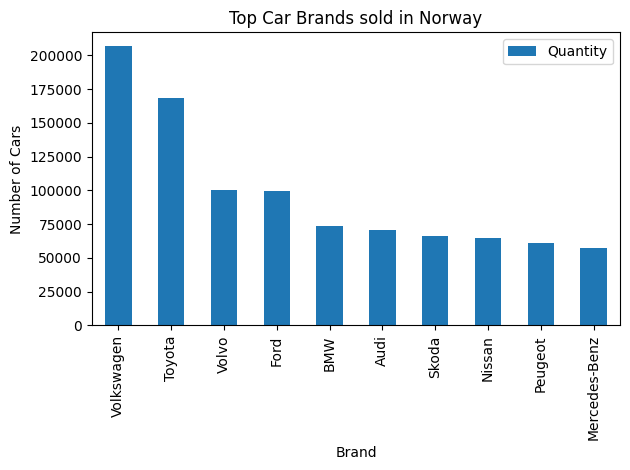

In [60]:
ax = df_top_10_brands.plot(kind="bar", title = "Top Car Brands sold in Norway", ylabel = "Number of Cars")
fig = ax.get_figure()
fig.tight_layout()
# TODO: Save fig

## Time for data storytelling.
- Attention.
- Contrast.
- Descriptive titles.
- Proximity with annotations.
- Remove clutter.
- Horizontal bar(hbar, currently its a vertical bar).
- Clearer xlabel and ylabel.
- Percentages instead of Absolute values.

In [70]:
# Göra om våra top 10 som procent istället
# df_top_10_brands["Quantity"]
# Summerar totalen
total_quantity = df_qty_brand["Quantity"].sum() 

# Räknar ut procenten
df_percentage = df_top_10_brands["Quantity"]  / total_quantity * 100 
df_percentage

Brand
Volkswagen       15.340063
Toyota           12.482984
Volvo             7.417851
Ford              7.401225
BMW               5.441826
Audi              5.231026
Skoda             4.899388
Nissan            4.790128
Peugeot           4.530191
Mercedes-Benz     4.272184
Name: Quantity, dtype: float64

In [207]:
colors = [GRAY_1]*len(df_percentage)
colors[2] = BLUE_1



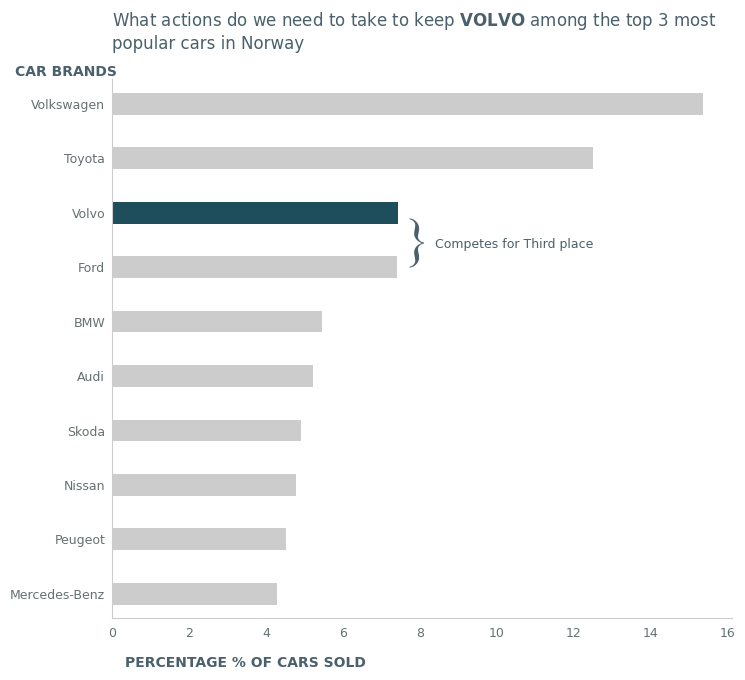

In [281]:
ax = df_percentage.plot(kind="barh", figsize=(8, 7), width=0.4, color = colors)
# Ta bort spines
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)
# Tick parametrar
ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0, pad=6)
ax.tick_params(axis="y", pad=5)
# Axlar
ax.set_xlabel("PERCENTAGE % OF CARS SOLD", color=GRAY_3, fontweight="bold")
ax.set_ylabel("CAR BRANDS", color=GRAY_3, fontweight="bold", rotation=0)

# Position på labels
ax.yaxis.set_label_coords(-0.075, 1)
ax.xaxis.set_label_coords(0.215, -0.07)

# Titel
ax.set_title(
    "What actions do we need to take to keep"
    + r" $\bf{VOLVO}$"
    + " among the top 3 most \npopular cars in Norway",
    loc="left",
    color=GRAY_3,
    pad=22,
)

ax.invert_yaxis()

ax.annotate(xy = (8.4, 2.64), text = "Competes for Third place", color=GRAY_3, fontsize=9)
ax.annotate(xy = (7.6, 2.8), text = "}", color=GRAY_3, fontsize=38, family="Times new roman")
figure = ax.get_figure()
figure.savefig("figures/cars_brand_sold_fixed")